# Week 5 · Notebook 1 — Particle Swarm Optimization

**Goals**
- Describe PSO precisely as a population of trajectories with *memory* (personal bests), an *information graph*
  (topology) and a *stochastic linear variation rule* (the velocity update) — no metaphor required.
- Derive the Clerc–Kennedy constriction coefficient, verify $\chi(4.1)\approx 0.7298$ numerically and prove the
  algebraic equivalence of the constriction and inertia-weight forms (then confirm it on identical random streams).
- Implement a vectorised PSO (many independent runs at once) with velocity clamping, three boundary-handling rules and
  three topologies (gbest, lbest ring, von Neumann).
- Measure, over many seeds and at equal evaluation budgets, the speed-vs-robustness trade-off of topologies, the
  effect of $v_{\max}$ and of boundary handling, and the rotation (in)variance that motivated SPSO-2011.

**Prerequisites:** Week 1 (benchmarks, evaluation budgets, landscape vocabulary), basic linear algebra.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import BENCHMARKS, BudgetedObjective, shifted_rotated, random_rotation, ellipsoid, PALETTE
from scipy.stats import mannwhitneyu

## 1. History and the mechanism-level definition

PSO was introduced by **Kennedy & Eberhart (1995)**, *Particle swarm optimization*, Proc. IEEE ICNN, pp. 1942–1948,
with the local-best ("lbest") variant discussed in **Eberhart & Kennedy (1995)**, MHS'95. The original rule had no
inertia weight and relied on a velocity clamp $v_{\max}$. **Shi & Eberhart (1998)**, *A modified particle swarm
optimizer* (IEEE ICEC), introduced the inertia weight $w$; **Clerc & Kennedy (2002)**, *The particle swarm —
explosion, stability, and convergence in a multidimensional complex space*, IEEE TEC 6(1):58–73, derived the
constriction coefficient $\chi$. **Kennedy & Mendes (2002)** studied population topologies (ring, von Neumann, …).

A swarm of $n$ particles lives in $\mathbb{R}^d$. Particle $i$ keeps

| symbol | role (mechanism) |
|---|---|
| $x_i$ | current position = the candidate solution that is evaluated |
| $v_i$ | velocity = the last displacement, carried over as *momentum* |
| $p_i$ | personal best = **memory** (elitist, per particle) |
| $l_i$ | best $p_j$ among the neighbours $j\in\mathcal N(i)$ of an **information graph** |

The update, applied coordinate-wise with fresh $r_1, r_2\sim U(0,1)^d$, is

$$
v_i \leftarrow w\,v_i + c_1\,r_1\odot(p_i-x_i) + c_2\,r_2\odot(l_i-x_i),\qquad x_i\leftarrow x_i+v_i ,
$$

followed by greedy memory replacement $p_i\leftarrow x_i$ if $f(x_i)<f(p_i)$. In mechanism terms: **representation**
real vectors; **variation** a stochastic, coordinate-wise weighted combination of the current point, the previous
displacement and two attractors; **selection** only in the memory ($p_i$ is replaced greedily, particles are never
discarded); **information sharing** through the graph $\mathcal N$. There is no crossover and no explicit step-size
adaptation: the step size shrinks only because the attractors $p_i$, $l_i$ and $x_i$ converge.

```text
PSO(f, n, w, c1, c2, topology, budget)
  x_i ~ U(box), v_i = (U(box) - x_i)/2, p_i = x_i                 # n evaluations
  while evaluations < budget:
    for each i: l_i = argmin_{j in N(i)} f(p_j)
    v_i = w v_i + c1 r1*(p_i - x_i) + c2 r2*(l_i - x_i)            # r1, r2 ~ U(0,1)^d
    v_i = clip(v_i, -vmax, vmax)                                   # optional
    x_i = x_i + v_i ; apply boundary rule
    evaluate f(x_i); if f(x_i) < f(p_i): p_i = x_i                 # n evaluations
  return best p_i
```

*AI relevance.* PSO is a popular derivative-free optimiser for hyperparameters and small architecture choices, and
for direct policy search with few parameters; the lab of this week tunes a kernel ridge model with it.

## 2. Constriction coefficient

Clerc & Kennedy write the update in *constriction form*

$$
v \leftarrow \chi\bigl[v + \varphi_1 r_1(p-x) + \varphi_2 r_2(l-x)\bigr],\qquad
\chi=\frac{2}{\left|2-\varphi-\sqrt{\varphi^2-4\varphi}\right|},\quad \varphi=\varphi_1+\varphi_2>4 .
$$

**Equivalence.** Expanding the bracket gives $v\leftarrow \chi v + (\chi\varphi_1)r_1(p-x)+(\chi\varphi_2)r_2(l-x)$,
i.e. the inertia form with $w=\chi$, $c_k=\chi\varphi_k$. With the standard $\varphi_1=\varphi_2=2.05$ this is
$w\approx0.7298$, $c_1=c_2\approx1.49618$ — the "default" parameters used throughout this week.

**An algebraic characterisation.** For $\varphi>4$ put $s=\varphi-2+\sqrt{\varphi^2-4\varphi}>0$, so $\chi=2/s$.
Since $s$ is a root of $s^2-2(\varphi-2)s+4=0$, substituting $s=2/\chi$ gives

$$
\chi^2-(\varphi-2)\chi+1=0 ,
$$

and $\chi$ is the *smaller* root (the product of the roots is 1). We verify both the closed form and this root
characterisation, and then that the constricted one-particle recurrence
$y_{t+1}=(1+\chi-\chi\varphi')y_t-\chi y_{t-1}$ is stable for every realised $\varphi'\in(0,\varphi]$ (Notebook 2
derives this recurrence).

In [2]:
def constriction(phi):
    """Clerc-Kennedy constriction coefficient chi(phi), phi > 4."""
    return 2.0 / abs(2.0 - phi - np.sqrt(phi**2 - 4.0 * phi))

chi = constriction(4.1)
roots = np.sort(np.roots([1.0, -(4.1 - 2.0), 1.0]).real)       # independent: roots of chi^2-(phi-2)chi+1
print(f"chi(4.1) = {chi:.9f},  c = chi*2.05 = {chi*2.05:.6f},  roots of quadratic = {roots}")
check_close(chi, 0.729843788, "chi(4.1) closed form", atol=1e-9)
check_close(chi, roots[0], "chi equals the smaller root of chi^2-(phi-2)chi+1", atol=1e-12)
check_close(chi * 2.05, 1.49618, "c = chi*phi_k = 1.49618", atol=5e-6)

# stability of the constricted recurrence for every realised phi' in (0, phi], for a range of phi > 4
worst = 0.0
for phi in np.linspace(4.01, 8.0, 60):
    ch = constriction(phi)
    for phi_r in np.linspace(1e-3, phi, 200):
        lam = np.roots([1.0, -(1.0 + ch - ch * phi_r), ch])
        worst = max(worst, np.abs(lam).max())
print(f"largest eigenvalue modulus over the grid: {worst:.4f}")
check_true(worst < 1.0, "constricted one-particle recurrence is stable for all phi' in (0, phi], phi in (4, 8]")

chi(4.1) = 0.729843788,  c = chi*2.05 = 1.496180,  roots of quadratic = [0.72984379 1.37015621]
[PASS] chi(4.1) closed form: got 0.729844, expected 0.729844
[PASS] chi equals the smaller root of chi^2-(phi-2)chi+1: got 0.729844, expected 0.729844
[PASS] c = chi*phi_k = 1.49618: got 1.49618, expected 1.49618


largest eigenvalue modulus over the grid: 0.9998
[PASS] constricted one-particle recurrence is stable for all phi' in (0, phi], phi in (4, 8]


## 3. A vectorised implementation

To make multi-seed statistics cheap we vectorise over **independent runs**: arrays have shape
`(runs, n, d)`, each run has its own swarm, and the objective is called once per iteration on all
`runs * n` points (every benchmark in `utils` accepts a batch). Each run spends exactly `n` evaluations per
iteration, so evaluation counting is explicit and identical across runs; we record the best-so-far value of every
run after every iteration.

**Topologies** are given as a neighbour index array `(n, k)` that includes the particle itself:
gbest ($k=n$), lbest ring ($k=3$), von Neumann (2-D torus grid, $k=5$).

**Boundary handling** (Helwig, Branke & Mostaghim 2013, IEEE TEC 17(2), compare many variants):
*absorb* — clip the coordinate to the bound and zero that velocity component; *reflect* — mirror the coordinate at the
bound and flip the velocity component; *random* — resample the offending coordinate uniformly and set the velocity to
the displacement actually made.

**Velocity clamping** $|v_{ij}|\le v_{\max}=k\,(u-\ell)$ was essential in the 1995 algorithm, which had $w=1$.

**SPSO-2011** (Clerc 2011; Zambrano-Bigiarini, Clerc & Rojas 2013) replaces the coordinate-wise rule by a
rotation-invariant one: with centre $G=x+c\,\frac{(p-x)+(l-x)}{3}$ (or $x+c\,\frac{p-x}{2}$ if $l=p$), sample
$x'$ uniformly in the ball $B(G,\Vert G-x\Vert)$ and set $v\leftarrow wv+x'-x$, with $w=1/(2\ln2)$,
$c=\tfrac12+\ln 2$. Because a ball is invariant under rotations about its centre, the distribution of the new
position is rotation-equivariant; the coordinate-wise $r_1\odot(p-x)$ is not (it favours the axis directions).
We implement this rule with a fixed ring topology (the full SPSO-2011 also uses an adaptive random topology).

In [3]:
def make_neighbourhood(n, topology):
    """(n, k) array of neighbour indices (self included); None means gbest."""
    idx = np.arange(n)
    if topology == "gbest":
        return None
    if topology == "ring":
        return np.stack([(idx - 1) % n, idx, (idx + 1) % n], axis=1)
    if topology == "vonneumann":
        rows = int(np.floor(np.sqrt(n)))
        while n % rows:
            rows -= 1
        cols = n // rows
        r, c = idx // cols, idx % cols
        return np.stack([idx, ((r - 1) % rows) * cols + c, ((r + 1) % rows) * cols + c,
                         r * cols + (c - 1) % cols, r * cols + (c + 1) % cols], axis=1)
    raise ValueError(topology)


def handle_bounds(X, Xold, V, lo, hi, mode, rng):
    """Apply a boundary-handling rule to proposed positions X (velocity V)."""
    if mode == "none":
        return X, V
    above, below = X > hi, X < lo
    out = above | below
    if not out.any():
        return X, V
    if mode == "absorb":
        return np.clip(X, lo, hi), np.where(out, 0.0, V)
    if mode == "reflect":
        X = np.where(above, 2 * hi - X, np.where(below, 2 * lo - X, X))
        return np.clip(X, lo, hi), np.where(out, -V, V)   # clip guards steps longer than the box
    if mode == "random":
        X = np.where(out, rng.uniform(lo, hi, X.shape), X)
        return X, np.where(out, X - Xold, V)
    raise ValueError(mode)


def pso(f, d, lo, hi, budget, runs=1, n=40, w=0.7298, c1=1.49618, c2=1.49618, topology="gbest",
        vmax=None, boundary="absorb", update="standard", rng=None, X0=None, V0=None):
    """Particle swarm optimisation, vectorised over `runs` independent swarms.

    w may be a float or a callable of the progress fraction in [0, 1] (time-varying inertia).
    vmax is None (no clamping) or a fraction of the box width.
    Returns dict with best values/points per run, the evaluation grid and the best-so-far trace (runs, T).
    """
    rng = np.random.default_rng() if rng is None else rng
    T = budget // n
    X = rng.uniform(lo, hi, (runs, n, d)) if X0 is None else X0.copy()
    V = (rng.uniform(lo, hi, (runs, n, d)) - X) / 2 if V0 is None else V0.copy()
    F = f(X.reshape(-1, d)).reshape(runs, n)
    evals = n
    P, Pf = X.copy(), F.copy()
    nbr = make_neighbourhood(n, topology)
    ar, own = np.arange(runs)[:, None], np.arange(n)[None, :]
    vm = None if vmax is None else vmax * (hi - lo)
    trace = [Pf.min(1)]
    for t in range(1, T):
        if nbr is None:
            gi = np.broadcast_to(Pf.argmin(1)[:, None], (runs, n))
        else:
            gi = nbr[np.arange(n), Pf[:, nbr].argmin(2)]          # (runs, n) index of neighbourhood best
        L = P[ar, gi]
        wt = w(t / max(T - 1, 1)) if callable(w) else w
        if update == "standard":
            r = rng.random((2, runs, n, d))
            V = wt * V + c1 * r[0] * (P - X) + c2 * r[1] * (L - X)
        elif update == "spso2011":
            same = (gi == own)[..., None]
            G = np.where(same, X + c1 * (P - X) / 2, X + c1 * (P + L - 2 * X) / 3)
            rad = np.linalg.norm(G - X, axis=2, keepdims=True)
            u = rng.standard_normal((runs, n, d))
            u /= np.linalg.norm(u, axis=2, keepdims=True)
            Xp = G + rad * rng.random((runs, n, 1)) ** (1.0 / d) * u
            V = wt * V + Xp - X
        else:
            raise ValueError(update)
        if vm is not None:
            V = np.clip(V, -vm, vm)
        Xnew, V = handle_bounds(X + V, X, V, lo, hi, boundary, rng)
        X = Xnew
        F = f(X.reshape(-1, d)).reshape(runs, n)
        evals += n
        imp = F < Pf
        P[imp], Pf[imp] = X[imp], F[imp]
        trace.append(Pf.min(1))
    b = Pf.argmin(1)
    return dict(best_f=Pf[np.arange(runs), b], best_x=P[np.arange(runs), b], evals=evals,
                grid=n * np.arange(1, T + 1), trace=np.array(trace).T, X=X, V=V)

## 4. Validation

1. **Constriction ≡ inertia, on identical random streams.** An independent, deliberately naive single-swarm loop
   written in *constriction form* must reproduce the vectorised inertia-form implementation trajectory for
   trajectory when both consume the same random numbers.
2. **Evaluation accounting.** Wrapping the objective in `BudgetedObjective` (which counts every row and records
   the best value it has ever seen) must agree with the algorithm's own counter and its reported best.
3. **Topology graphs** must be symmetric with the stated degree; **boundary rules** must keep every particle inside
   the box.
4. **Known optimum.** On the sphere ($f^{\ast}=0$ at the origin) constriction PSO must converge to machine-level error.

In [4]:
def pso_constriction_naive(f, X0, V0, iters, phi1, phi2, rng):
    """Reference gbest PSO written in Clerc-Kennedy constriction form, one swarm, plain loop."""
    ch = constriction(phi1 + phi2)
    x, v = X0.copy(), V0.copy()
    p, pf = x.copy(), f(x)
    for _ in range(iters):
        g = p[np.argmin(pf)]
        r1 = rng.random(x.shape)
        r2 = rng.random(x.shape)
        v = ch * (v + phi1 * r1 * (p - x) + phi2 * r2 * (g - x))
        x = x + v
        fx = f(x)
        better = fx < pf
        p[better], pf[better] = x[better], fx[better]
    return x, pf

d, n, iters = 5, 20, 60
f_rast = BENCHMARKS["rastrigin"].f
X0 = rng.uniform(-5.12, 5.12, (n, d)); V0 = rng.uniform(-1, 1, (n, d))
x_ref, pf_ref = pso_constriction_naive(f_rast, X0, V0, iters, 2.05, 2.05, np.random.default_rng(7))
res = pso(f_rast, d, -5.12, 5.12, budget=n * (iters + 1), runs=1, n=n, w=chi, c1=chi * 2.05, c2=chi * 2.05,
          boundary="none", rng=np.random.default_rng(7), X0=X0[None], V0=V0[None])
check_close(np.abs(res["X"][0] - x_ref).max(), 0.0, "max |x_inertia - x_constriction| over all particles", atol=1e-8)
check_close(res["trace"][0, -1], pf_ref.min(), "best value after 60 iterations, both forms", atol=1e-10)

# evaluation accounting against the independent BudgetedObjective counter
bo = BudgetedObjective(BENCHMARKS["sphere"].f, budget=4000)
res = pso(bo, 10, -5.12, 5.12, budget=4000, runs=1, rng=np.random.default_rng(1))
check_true(bo.evals == res["evals"] == 4000, f"evaluation count: BudgetedObjective={bo.evals}, PSO={res['evals']}")
check_close(res["best_f"][0], bo.best_f, "best value reported by PSO equals best seen by the counter", atol=0)

# topology graphs: symmetric adjacency, correct degree
for topo, deg in [("ring", 3), ("vonneumann", 5)]:
    nb = make_neighbourhood(40, topo)
    A = np.zeros((40, 40), bool); A[np.repeat(np.arange(40), nb.shape[1]), nb.ravel()] = True
    check_true((A == A.T).all() and (A.sum(1) == deg).all(), f"{topo}: symmetric, every node has degree {deg} (self incl.)")

# boundary rules keep particles inside the box (Schwefel, whose optimum lies near the boundary)
for mode in ["absorb", "reflect", "random"]:
    r = pso(BENCHMARKS["schwefel"].f, 10, -500, 500, 4000, runs=5, boundary=mode, rng=np.random.default_rng(2))
    check_true(np.all((r["X"] >= -500) & (r["X"] <= 500)), f"boundary rule '{mode}' keeps all particles in the box")

# known optimum on the sphere
r = pso(BENCHMARKS["sphere"].f, 10, -5.12, 5.12, 20000, runs=10, rng=np.random.default_rng(3))
print(f"sphere d=10, 20000 evals, 10 runs: max final error = {r['best_f'].max():.2e}")
check_true(r["best_f"].max() < 1e-12, "constriction gbest-PSO reaches the sphere optimum f*=0 to < 1e-12 in every run")

[PASS] max |x_inertia - x_constriction| over all particles: got 0.0, expected 0.0
[PASS] best value after 60 iterations, both forms: got 2.783523, expected 2.783523
[PASS] evaluation count: BudgetedObjective=4000, PSO=4000
[PASS] best value reported by PSO equals best seen by the counter: got 3e-06, expected 3e-06
[PASS] ring: symmetric, every node has degree 3 (self incl.)
[PASS] vonneumann: symmetric, every node has degree 5 (self incl.)
[PASS] boundary rule 'absorb' keeps all particles in the box
[PASS] boundary rule 'reflect' keeps all particles in the box


[PASS] boundary rule 'random' keeps all particles in the box


sphere d=10, 20000 evals, 10 runs: max final error = 3.62e-24
[PASS] constriction gbest-PSO reaches the sphere optimum f*=0 to < 1e-12 in every run


## 5. Experiment 1 — topology: speed versus robustness

The information graph controls how fast the best position found anywhere propagates. In gbest every particle is
attracted to the same point after one iteration (diameter 1); in the ring, information needs up to $n/2$
iterations to cross the swarm; von Neumann (diameter $\approx\sqrt n$) is in between. Kennedy & Mendes (2002)
reported that von Neumann was a good compromise. We test $d=10$, $n=40$, a budget of $20\,000$ evaluations,
25 independent runs per cell, all with the constriction parameters and absorbing bounds.

In [5]:
FUNCS = ["sphere", "rosenbrock", "rastrigin", "ackley", "griewank", "schwefel"]
TOPOS = ["gbest", "vonneumann", "ring"]
D, BUDGET, RUNS = 10, 20000, 25

def med_iqr(a):
    q1, m, q3 = np.percentile(a, [25, 50, 75])
    return f"{m:9.2e} [{q1:8.1e},{q3:8.1e}]"

topo_res = {}
for fname in FUNCS:
    bm = BENCHMARKS[fname]
    for k, topo in enumerate(TOPOS):
        topo_res[fname, topo] = pso(bm.f, D, bm.lower, bm.upper, BUDGET, runs=RUNS, topology=topo,
                                    rng=np.random.default_rng(100 + k))
print(f"final error f - f*  (median [IQR], {RUNS} runs, d={D}, {BUDGET} evals)")
print(f"{'function':11s}" + "".join(f"{t:>30s}" for t in TOPOS) + "   MWU p: gbest-vN, gbest-ring")
for fname in FUNCS:
    fo = BENCHMARKS[fname].f_opt
    errs = [topo_res[fname, t]["best_f"] - fo for t in TOPOS]
    p1, p2 = mannwhitneyu(errs[0], errs[1]).pvalue, mannwhitneyu(errs[0], errs[2]).pvalue
    print(f"{fname:11s}" + "".join(f"{med_iqr(e):>30s}" for e in errs) + f"   {p1:.1e}, {p2:.1e}")

final error f - f*  (median [IQR], 25 runs, d=10, 20000 evals)
function                            gbest                    vonneumann                          ring   MWU p: gbest-vN, gbest-ring
sphere       1.37e-25 [ 7.5e-26, 4.2e-25]  1.67e-17 [ 6.4e-18, 3.8e-17]  1.05e-13 [ 3.0e-14, 2.4e-13]   1.4e-09, 1.4e-09
rosenbrock   2.60e+00 [ 2.1e+00, 3.0e+00]  4.78e+00 [ 3.6e+00, 4.9e+00]  1.90e+00 [ 7.3e-01, 4.8e+00]   2.5e-04, 4.7e-01
rastrigin    5.97e+00 [ 5.0e+00, 9.0e+00]  3.98e+00 [ 3.0e+00, 5.0e+00]  6.96e+00 [ 6.0e+00, 9.0e+00]   2.2e-03, 2.5e-01
ackley       5.13e-12 [ 2.6e-12, 7.1e-12]  3.16e-08 [ 2.2e-08, 7.1e-08]  3.08e-06 [ 2.0e-06, 5.2e-06]   1.4e-09, 1.4e-09
griewank     6.40e-02 [ 4.7e-02, 9.6e-02]  5.91e-02 [ 4.4e-02, 6.9e-02]  4.67e-02 [ 2.0e-02, 5.2e-02]   1.2e-01, 1.4e-04
schwefel     5.94e+02 [ 3.6e+02, 8.1e+02]  3.55e+02 [ 2.4e+02, 4.8e+02]  5.95e+02 [ 5.3e+02, 7.7e+02]   4.3e-03, 3.6e-01


In [6]:
def evals_to_target(res, target):
    """First evaluation count at which each run's best-so-far drops below target (inf if never)."""
    hit = res["trace"] < target
    first = np.where(hit.any(1), hit.argmax(1), -1)
    return np.where(first >= 0, res["grid"][first], np.inf)

for t in TOPOS:
    e = evals_to_target(topo_res["sphere", t], 1e-8)
    print(f"sphere, evaluations to reach 1e-8 [{t:10s}]: median {np.median(e):7.0f}")
e_g = evals_to_target(topo_res["sphere", "gbest"], 1e-8); e_r = evals_to_target(topo_res["sphere", "ring"], 1e-8)
check_true(np.median(e_g) < np.median(e_r), "gbest reaches 1e-8 on the sphere faster than the ring (median)")

sphere, evaluations to reach 1e-8 [gbest     ]: median    6920
sphere, evaluations to reach 1e-8 [vonneumann]: median   10160
sphere, evaluations to reach 1e-8 [ring      ]: median   12960
[PASS] gbest reaches 1e-8 on the sphere faster than the ring (median)


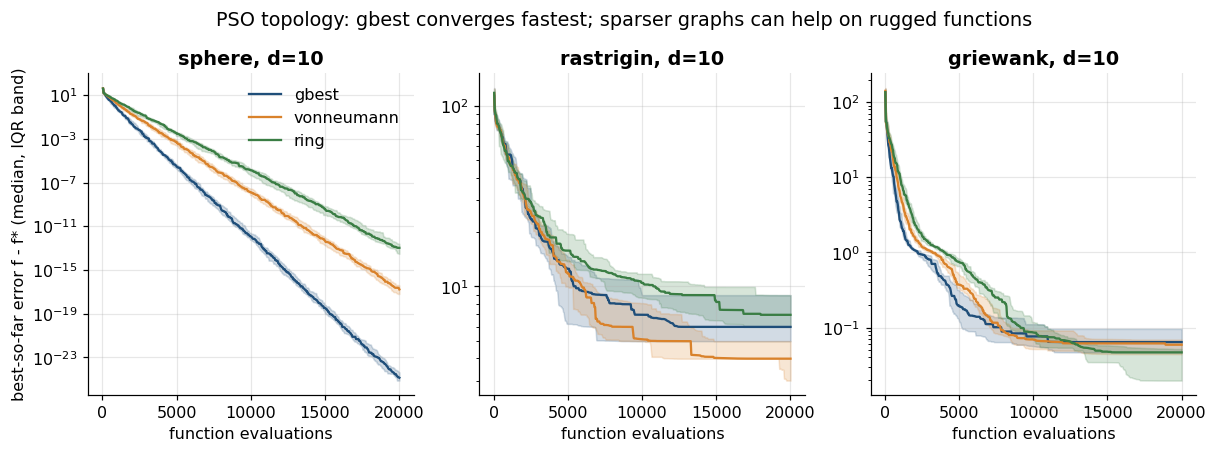

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, fname in zip(axes, ["sphere", "rastrigin", "griewank"]):
    for k, t in enumerate(TOPOS):
        r = topo_res[fname, t]
        q1, m, q3 = np.percentile(np.maximum(r["trace"], 1e-30), [25, 50, 75], axis=0)
        ax.plot(r["grid"], m, label=t, color=list(PALETTE.values())[k])
        ax.fill_between(r["grid"], q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
    ax.set_yscale("log"); ax.set_title(f"{fname}, d={D}"); ax.set_xlabel("function evaluations")
axes[0].set_ylabel("best-so-far error f - f* (median, IQR band)"); axes[0].legend()
plt.suptitle("PSO topology: gbest converges fastest; sparser graphs can help on rugged functions", y=1.03)
savefig("w5_pso_topologies.png"); plt.show()

**Reading the table.** The unimodal sphere shows the pure speed effect: gbest reaches $10^{-8}$ in far fewer
evaluations than von Neumann, which is faster than the ring, and the final errors are ordered the same way (the
Mann–Whitney p-values are tiny). Ackley behaves like the sphere at this budget: its global trend is a funnel, so fast
information flow pays off. On Rastrigin and Schwefel von Neumann has the lowest median error and on Griewank the ring
does, i.e. slower information flow helps on rugged multimodal landscapes — but several of these differences are not
significant with 25 runs (large p-values), which is exactly why we report them. No topology dominates: this is the
exploration–exploitation trade-off controlled by the graph diameter. Schwefel is deceptive (the best basin is near the
boundary, far from the second-best) and all three topologies usually end in sub-optimal basins.

## 6. Experiment 2 — the three historical parameterisations and velocity clamping

* **PSO-1995**: $w=1$, $c_1=c_2=2$ with $v_{\max}$ (here $v_{\max}=0.2\,(u-\ell)$, a common choice). Without the
  clamp this system diverges (Notebook 2 proves why).
* **Linearly decreasing inertia** $w: 0.9\to0.4$, $c_1=c_2=2$, clamped at $v_{\max}=0.5\,(u-\ell)$, i.e. $x_{\max}$
  for a symmetric box (Shi & Eberhart 1998/1999).
* **Constriction** $w=0.7298$, $c=1.49618$ (Clerc & Kennedy 2002), with and without clamping — Eberhart & Shi (2000)
  recommended clamping at $v_{\max}=x_{\max}$ even with constriction ($v_{\max}=0.5\,(u-\ell)$ here).

In [8]:
VARIANTS = {
    "PSO-1995 (w=1, c=2, vmax=0.2)": dict(w=1.0, c1=2.0, c2=2.0, vmax=0.2),
    "PSO-1995 without clamping": dict(w=1.0, c1=2.0, c2=2.0, vmax=None),
    "LDIW w:0.9->0.4, c=2": dict(w=lambda s: 0.9 - 0.5 * s, c1=2.0, c2=2.0, vmax=0.5),
    "constriction, no clamp": dict(vmax=None),
    "constriction, vmax=0.5": dict(vmax=0.5),
}
var_res = {}
for fname in ["sphere", "rosenbrock", "rastrigin", "ackley"]:
    bm = BENCHMARKS[fname]
    for k, (name, kw) in enumerate(VARIANTS.items()):
        var_res[fname, name] = pso(bm.f, D, bm.lower, bm.upper, BUDGET, runs=RUNS, topology="gbest",
                                   rng=np.random.default_rng(200 + k), **kw)
print(f"final error, median [IQR], {RUNS} runs, gbest, d={D}, {BUDGET} evals")
for fname in ["sphere", "rosenbrock", "rastrigin", "ackley"]:
    print(fname)
    for name in VARIANTS:
        r = var_res[fname, name]
        lo, hi = BENCHMARKS[fname].lower, BENCHMARKS[fname].upper
        on_bound = np.mean((r["X"] == lo) | (r["X"] == hi))
        print(f"   {name:32s} {med_iqr(r['best_f'])}   final |v| median {np.median(np.abs(r['V'])):.1e}"
              f"   coords on the bound {on_bound:5.1%}")

final error, median [IQR], 25 runs, gbest, d=10, 20000 evals
sphere
   PSO-1995 (w=1, c=2, vmax=0.2)     9.69e-01 [ 6.9e-01, 1.1e+00]   final |v| median 1.3e+00   coords on the bound  0.0%
   PSO-1995 without clamping         1.38e+01 [ 1.1e+01, 1.6e+01]   final |v| median 1.8e+00   coords on the bound 30.4%
   LDIW w:0.9->0.4, c=2              1.54e-14 [ 6.0e-15, 6.0e-14]   final |v| median 6.1e-08   coords on the bound  0.0%
   constriction, no clamp            1.99e-25 [ 9.7e-26, 5.0e-25]   final |v| median 1.9e-13   coords on the bound  0.0%
   constriction, vmax=0.5            2.45e-25 [ 7.5e-26, 3.8e-25]   final |v| median 1.9e-13   coords on the bound  0.0%
rosenbrock
   PSO-1995 (w=1, c=2, vmax=0.2)     2.56e+02 [ 1.9e+02, 3.1e+02]   final |v| median 1.9e+00   coords on the bound  0.0%
   PSO-1995 without clamping         7.93e+03 [ 6.2e+03, 1.1e+04]   final |v| median 2.5e+00   coords on the bound 26.7%
   LDIW w:0.9->0.4, c=2              4.98e+00 [ 2.8e+00, 5.7e+00]   final 

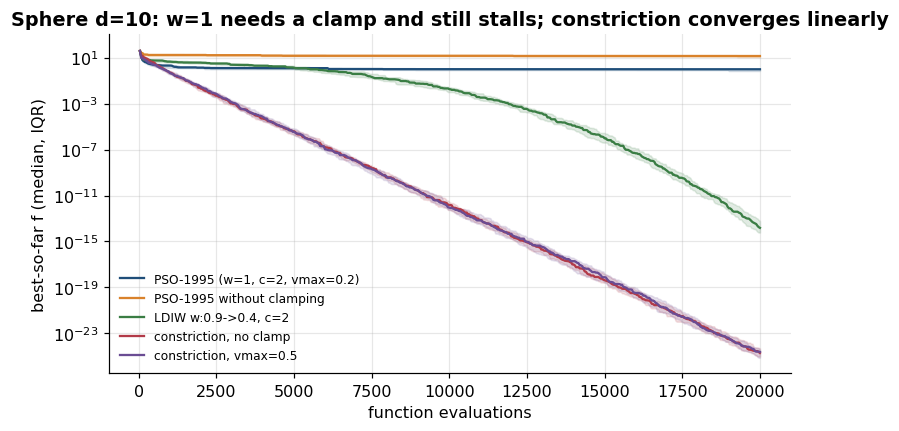

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for k, name in enumerate(VARIANTS):
    r = var_res["sphere", name]
    q1, m, q3 = np.percentile(np.maximum(r["trace"], 1e-30), [25, 50, 75], axis=0)
    ax.plot(r["grid"], m, label=name, color=list(PALETTE.values())[k])
    ax.fill_between(r["grid"], q1, q3, alpha=0.15, color=list(PALETTE.values())[k])
ax.set_yscale("log"); ax.set_xlabel("function evaluations"); ax.set_ylabel("best-so-far f (median, IQR)")
ax.set_title("Sphere d=10: w=1 needs a clamp and still stalls; constriction converges linearly"); ax.legend(fontsize=8)
savefig("w5_pso_parameterisations.png"); plt.show()

With $w=1$ the swarm never contracts: the clamp keeps it bounded but the step size stays of the order of $v_{\max}$,
so the error plateaus far from the optimum. Without the clamp the velocities grow until particles leave the box; the
absorbing rule then zeroes the offending velocity components and pins those coordinates to the bound (see the
"coords on the bound" column), which is the observable face of swarm explosion here (Notebook 2 shows the unbounded
growth without any bound handling). Constriction converges linearly (straight line on the log scale) with or without
a clamp. The linearly decreasing inertia weight explores longer and converges only when $w$ has become small; it is
competitive (on Rastrigin the best of the five) but its schedule is tied to the budget, a design weakness.

## 7. Experiment 3 — boundary handling

Boundary rules matter most when the optimum lies near the boundary (Schwefel: $x^{\ast}_j\approx420.97$ in
$[-500,500]$) and when many particles leave the box (early iterations, large velocities).

final error, median [IQR], von Neumann, 25 runs
schwefel    absorb:  3.57e+02 [ 3.6e+02, 4.8e+02]  reflect:  1.18e+02 [ 1.3e-05, 1.2e+02]  random:  4.74e+02 [ 3.6e+02, 6.5e+02]
rastrigin   absorb:  5.97e+00 [ 4.0e+00, 8.0e+00]  reflect:  4.97e+00 [ 3.0e+00, 6.0e+00]  random:  4.35e+00 [ 3.0e+00, 5.0e+00]
ackley      absorb:  3.52e-08 [ 2.0e-08, 5.5e-08]  reflect:  6.42e-08 [ 3.4e-08, 8.0e-08]  random:  3.23e-08 [ 2.7e-08, 4.9e-08]


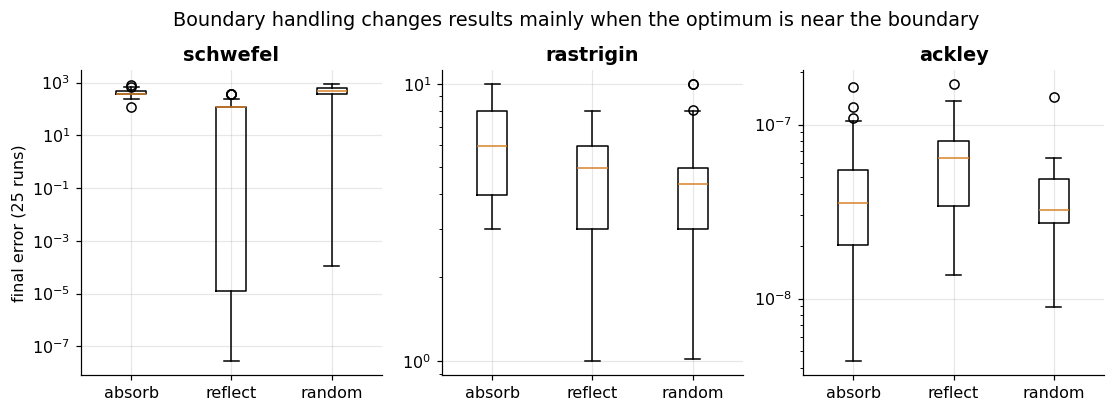

In [10]:
BOUNDS = ["absorb", "reflect", "random"]
bnd_res = {}
for fname in ["schwefel", "rastrigin", "ackley"]:
    bm = BENCHMARKS[fname]
    for k, mode in enumerate(BOUNDS):
        bnd_res[fname, mode] = pso(bm.f, D, bm.lower, bm.upper, BUDGET, runs=RUNS, topology="vonneumann",
                                   boundary=mode, rng=np.random.default_rng(300 + k))
print(f"final error, median [IQR], von Neumann, {RUNS} runs")
for fname in ["schwefel", "rastrigin", "ackley"]:
    print(f"{fname:10s}" + "".join(f"  {m}: {med_iqr(bnd_res[fname, m]['best_f'] - BENCHMARKS[fname].f_opt)}" for m in BOUNDS))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, fname in zip(axes, ["schwefel", "rastrigin", "ackley"]):
    data = [bnd_res[fname, m]["best_f"] - BENCHMARKS[fname].f_opt + 1e-12 for m in BOUNDS]
    ax.boxplot(data, tick_labels=BOUNDS); ax.set_yscale("log"); ax.set_title(fname)
axes[0].set_ylabel(f"final error ({RUNS} runs)")
plt.suptitle("Boundary handling changes results mainly when the optimum is near the boundary", y=1.03)
savefig("w5_pso_boundaries.png"); plt.show()

On Schwefel the rule matters a lot: *reflect* has a much lower median error than *absorb* and *random*, and its lower
quartile shows runs that located the global basin next to the boundary. Absorbing pins particles on the bound and
kills their velocity, which makes the swarm lose momentum exactly where the optimum is; reflecting keeps them
moving back into the region near the boundary. On Rastrigin and Ackley (optimum at the centre) the differences are
small. The rule is part of the algorithm and must be reported.

## 8. Experiment 4 — rotation (in)variance and SPSO-2011

The coordinate-wise random factors $r_1\odot(p-x)$ make standard PSO sensitive to the coordinate system: its search
distribution is concentrated in the box spanned by $x,p,l$, whose edges are axis-parallel. On a *separable*
ill-conditioned function the axes are exactly the right directions; after a random rotation they are not
(Wilke, Kok & Groenwold 2007; Spears, Green & Spears 2010). We compare the shifted ellipsoid
$f(x-s)$ with the shifted-rotated one $f(R(x-s))$ (condition number $10^6$, $d=10$, same shift $s$, Haar-random
$R$), for standard PSO and for the SPSO-2011 update, both with a ring topology.

standard  shifted:  5.11e-17 [ 1.8e-17, 2.8e-16]   rotated:  3.18e+02 [ 1.9e+02, 9.2e+02]   median ratio rotated/plain = 6.2e+18   MWU p = 1.4e-09
          median final swarm radius: shifted 7.6e-09, rotated 6.2e+00  (a uniform swarm in the box has radius ~9.1)
spso2011  shifted:  3.57e+03 [ 1.2e+03, 5.0e+03]   rotated:  2.15e+03 [ 1.3e+03, 3.4e+03]   median ratio rotated/plain = 6.0e-01   MWU p = 2.1e-01
          median final swarm radius: shifted 7.5e+00, rotated 7.7e+00  (a uniform swarm in the box has radius ~9.1)
[PASS] standard PSO is >100x worse (median) on the rotated ellipsoid


SPSO-2011 stagnating particle, Lyapunov exponent per iteration by dimension: {1: -0.108, 2: -0.058, 5: 0.021, 10: 0.066, 30: 0.102}
[PASS] SPSO-2011 defaults: stagnating particle contracts for d=2 but not for d=10


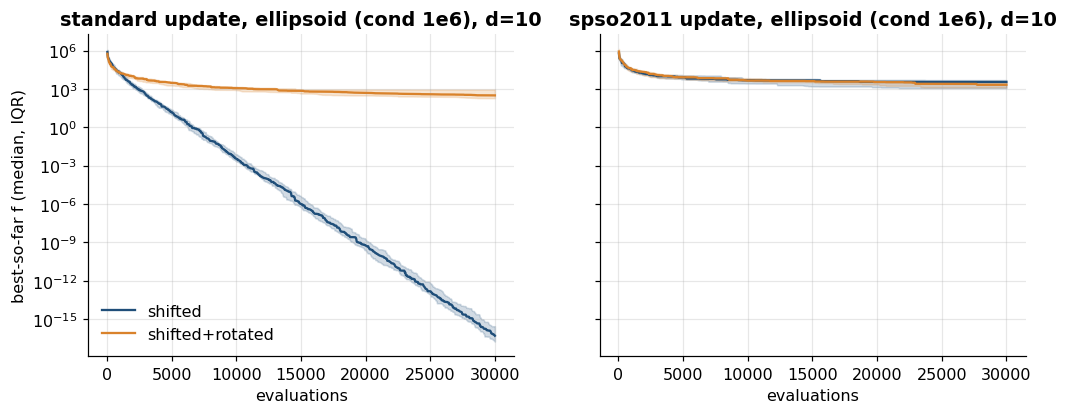

In [11]:
d_rot = 10
shift = np.random.default_rng(11).uniform(-2, 2, d_rot)
R = random_rotation(d_rot, np.random.default_rng(12))
f_plain = shifted_rotated(ellipsoid, shift, np.eye(d_rot))
f_rot = shifted_rotated(ellipsoid, shift, R)
w11, c11 = 1 / (2 * np.log(2)), 0.5 + np.log(2)
rot_res = {}
for k, (upd, kw) in enumerate([("standard", {}), ("spso2011", dict(w=w11, c1=c11, c2=c11))]):
    for fn_name, fn in [("shifted", f_plain), ("shifted+rotated", f_rot)]:
        rot_res[upd, fn_name] = pso(fn, d_rot, -5, 5, 30000, runs=RUNS, topology="ring", update=upd,
                                    rng=np.random.default_rng(400 + k), **kw)
ratios, radius = {}, {}
for upd in ["standard", "spso2011"]:
    a, b = rot_res[upd, "shifted"]["best_f"], rot_res[upd, "shifted+rotated"]["best_f"]
    ratios[upd] = np.median(b) / np.median(a)
    for fn_name in ["shifted", "shifted+rotated"]:
        Xf = rot_res[upd, fn_name]["X"]
        radius[upd, fn_name] = np.median(np.linalg.norm(Xf - Xf.mean(1, keepdims=True), axis=2).mean(1))
    print(f"{upd:9s} shifted: {med_iqr(a)}   rotated: {med_iqr(b)}   median ratio rotated/plain = {ratios[upd]:.1e}"
          f"   MWU p = {mannwhitneyu(a, b).pvalue:.1e}")
    print(f"{'':9s} median final swarm radius: shifted {radius[upd, 'shifted']:.1e}, rotated {radius[upd, 'shifted+rotated']:.1e}"
          f"  (a uniform swarm in the box has radius ~{np.sqrt(d_rot * 100 / 12):.1f})")
check_true(ratios["standard"] > 100, "standard PSO is >100x worse (median) on the rotated ellipsoid")

# Why SPSO-2011 is poor here: stability of the stagnating SPSO-2011 particle depends on the dimension.
# With p = l = 0 fixed (the particle is not its own best), G = x(1 - 2c/3) and x' is uniform in B(G, |G - x|);
# the map (x, v) -> (x', v') is linear in (x, v) for fixed random draws, so the growth rate of |x| is a Lyapunov
# exponent, estimated here with renormalisation (4000 particles, 300 steps).
def spso_stagnation_lyapunov(d, rng, N=4000, T=300, w=w11, c=c11):
    x, v, logs = rng.standard_normal((N, d)), np.zeros((N, d)), []
    for t in range(T):
        G = x * (1 - 2 * c / 3)
        u = rng.standard_normal((N, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
        xp = G + np.linalg.norm(G - x, axis=1, keepdims=True) * rng.random((N, 1)) ** (1.0 / d) * u
        v = w * v + xp - x; x = x + v
        nx = np.linalg.norm(x, axis=1, keepdims=True); logs.append(np.log(nx).mean()); x /= nx; v /= nx
    return np.mean(logs[50:]), np.std(logs[50:]) / np.sqrt(T - 50)
lyap11 = {dd: spso_stagnation_lyapunov(dd, np.random.default_rng(13)) for dd in (1, 2, 5, 10, 30)}
print("SPSO-2011 stagnating particle, Lyapunov exponent per iteration by dimension:",
      {dd: round(float(g), 3) for dd, (g, _) in lyap11.items()})
check_true(lyap11[2][0] < 0 < lyap11[10][0], "SPSO-2011 defaults: stagnating particle contracts for d=2 but not for d=10")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, upd in zip(axes, ["standard", "spso2011"]):
    for k, fn_name in enumerate(["shifted", "shifted+rotated"]):
        r = rot_res[upd, fn_name]
        q1, m, q3 = np.percentile(r["trace"], [25, 50, 75], axis=0)
        ax.plot(r["grid"], m, label=fn_name, color=list(PALETTE.values())[k])
        ax.fill_between(r["grid"], q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
    ax.set_yscale("log"); ax.set_title(f"{upd} update, ellipsoid (cond 1e6), d=10"); ax.set_xlabel("evaluations")
axes[0].set_ylabel("best-so-far f (median, IQR)"); axes[0].legend()
savefig("w5_pso_rotation.png"); plt.show()

The standard update is excellent on the separable ellipsoid and dramatically worse after rotation. For the SPSO-2011
update the two medians are statistically indistinguishable at this sample size, as rotation-equivariance predicts —
but the rule is much *worse* than the standard update on both functions. The reason is **not** premature
contraction. On the separable ellipsoid the standard swarm contracts to a tiny radius, whereas the SPSO-2011 swarm
still has a radius of the order of the box on both functions: it never converges. (On the rotated ellipsoid the
standard ring swarm has not contracted either; there its axis-aligned steps make progress slow.)
The last computation explains the SPSO-2011 behaviour. In $d$ dimensions a point drawn uniformly in the ball $B(G,\Vert G-x\Vert)$ lies
almost on its surface, so its distance to the attractor hardly shrinks, and the momentum term then makes the
stagnating particle *unstable* once $d$ is large enough (positive Lyapunov exponent for $d\ge5$ with the default
$w=1/(2\ln2)$, $c=\tfrac12+\ln2$). The stability region of SPSO-2011 depends on the dimension, which is one of the results of
Bonyadi & Michalewicz (2014), *SPSO 2011: analysis of stability; local convergence; and rotation sensitivity*,
GECCO 2014, pp. 9–16 (they also prove that the algorithm is rotation invariant and not locally convergent in general).
Here only the absorbing bounds keep the swarm inside the box. Invariance removes a bias that helps on separable
problems; it is not by itself a performance guarantee. (Published SPSO-2011 codes differ in details such as the
radial distribution in the hypersphere and the random topology, which affect this behaviour.) Even SPSO-2011 is not
fully invariant: the initialisation box and the boundary rule are axis-aligned. Week 6's CMA-ES is invariant *and*
adapts its search distribution.

## Key takeaways

- PSO = per-particle elitist memory + a stochastic coordinate-wise linear variation rule + an information graph.
  Step sizes shrink only through the convergence of attractors, not by explicit adaptation.
- Constriction and inertia forms are algebraically identical ($w=\chi$, $c_k=\chi\varphi_k$);
  $\chi(4.1)=0.72984$ is the smaller root of $\chi^2-(\varphi-2)\chi+1=0$, giving the default $c=1.49618$.
- $w=1$ (PSO-1995) needs $v_{\max}$ and still does not converge; constriction converges with or without clamping.
- Topology is the main exploration knob: gbest is fastest on unimodal problems, ring / von Neumann trade speed for
  robustness on multimodal ones.
- Boundary handling is a real design decision when optima are near the boundary.
- Coordinate-wise randomness makes standard PSO rotation-variant; SPSO-2011's hypersphere sampling makes the update
  rotation-equivariant, but with uniform hypersphere sampling its default parameters are unstable in $d=10$ (the
  stability region depends on the dimension), so the swarm never contracts: invariance is not performance.

## Exercises

1. ★ Show that the gbest topology is the limit of lbest with neighbourhood radius $\ge n/2$, and compute the graph
   diameter of the ring, von Neumann ($r\times c$ torus) and gbest topologies as functions of $n$.
2. ★ Prove that for $\varphi>4$ the constriction coefficient satisfies $0<\chi<1$ and is decreasing in $\varphi$.
   Plot $\chi(\varphi)$ and $c=\chi\varphi/2$ for $\varphi\in(4,8]$.
3. ★★ Implement the *fully informed particle swarm* (Mendes, Kennedy & Neves 2004), in which every neighbour
   contributes an attractor, and compare it with the ring and von Neumann variants of Section 5 at equal budgets.
4. ★★ Show that, conditionally on $x,p,l$, the standard update's new position lies in an axis-aligned box and compute
   its covariance matrix. Deduce why the search distribution is not rotation-equivariant.
5. ★★ Add the "infinity"/let-them-fly bound rule (infeasible particles are not evaluated and cannot update $p_i$) and
   compare it with the three rules of Section 7. How should the evaluation budget be accounted for?
6. ★★★ Implement the full SPSO-2011 adaptive random topology (each particle informs $K=3$ random others; the graph
   is resampled after an iteration without improvement of the global best) and repeat the rotation experiment on the
   rotated Rastrigin function with 25 seeds.